In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
import pandas as pd

data = pd.read_csv('./data/huggingface_dataset.csv', low_memory=False)

In [29]:
len(data)

942292

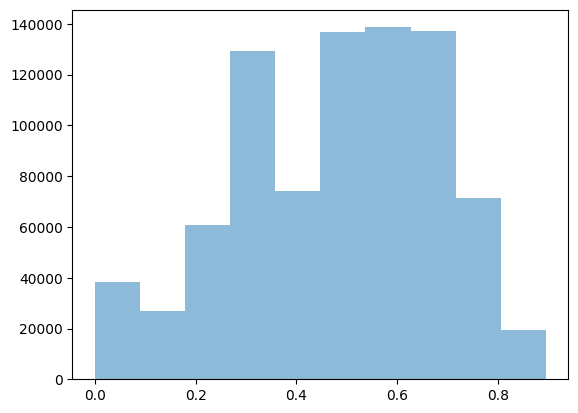

In [14]:
import matplotlib.pyplot as plt

plt.hist(data['jaccard_similarity'], bins=10, alpha=0.5)
plt.show()


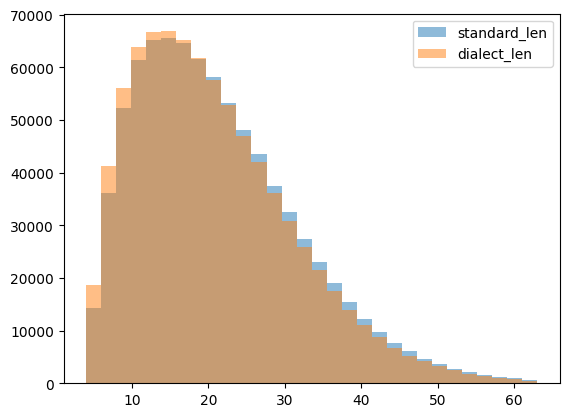

In [15]:
import matplotlib.pyplot as plt

plt.hist(data['standard_len'], bins=30, alpha=0.5, label='standard_len')
plt.hist(data['dialect_len'], bins=30, alpha=0.5, label='dialect_len')
plt.legend()
plt.show()

In [38]:
data[(data['standard_len'] < 10) & (data['jaccard_similarity'] < 0.1)]
dropped_df = data.drop(index=data[(data['standard_len'] > 9) & (data['standard_len'] < 40) & (data['jaccard_similarity'] < 0.1)].index)
dropped_df = dropped_df.drop(index=dropped_df[(dropped_df['standard_len'] > 40) & (dropped_df['jaccard_similarity'] < 0.1)].index)
dropped_df = dropped_df.drop(index=dropped_df[(dropped_df['standard_len'] > 9) & (dropped_df['standard_len'] < 40) & (dropped_df['jaccard_similarity'] > 0.8)].index)
dropped_df = dropped_df.drop(index=dropped_df[(dropped_df['standard_len'] > 40) & (dropped_df['jaccard_similarity'] > 0.8)].index)
dropped_df = dropped_df.dropna(axis=0)

In [39]:
len(dropped_df)

796935

In [44]:
final_df = dropped_df[['standard_form', 'dialect_form']]
final_df.head()

,standard_form,dialect_form
0,어 그거 튀겨서,어 그거 튀겨그네
1,돌멩이 해 가지고 실명된사람 있어,돌멩이 해 가지고 실명된사람 이서
2,그러니까 제주도는 워낙 또 돌멩이가 많아서,거난 제주도는 워낙 또 돌멩이가 많아그네
3,그러니깐,겅하니깐
4,데리고 가고 싶어서 할아버지가이,데리고 가고 싶어그네 할아버지가이


In [45]:
final_df.to_csv('./data/filtered_huggingface_dataset.csv', index=False, encoding='utf-8-sig')

In [46]:
t = pd.read_csv('./data/filtered_huggingface_dataset.csv')
t.head()

,standard_form,dialect_form
0,어 그거 튀겨서,어 그거 튀겨그네
1,돌멩이 해 가지고 실명된사람 있어,돌멩이 해 가지고 실명된사람 이서
2,그러니까 제주도는 워낙 또 돌멩이가 많아서,거난 제주도는 워낙 또 돌멩이가 많아그네
3,그러니깐,겅하니깐
4,데리고 가고 싶어서 할아버지가이,데리고 가고 싶어그네 할아버지가이
